<a href="https://colab.research.google.com/github/crossbone72/AI-Class/blob/main/Weak7/DL_Wine_Pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

import matplotlib.pyplot as plt
from torchsummary import summary
import numpy as np

data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/wine.csv')
data

,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,3,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740
174,3,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750
175,3,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835
176,3,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840


<Axes: ylabel='count'>

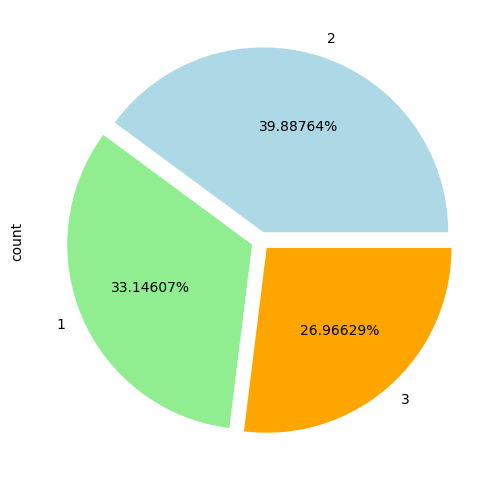

In [2]:
# 그래프 크기 설정
fig_size = plt.rcParams["figure.figsize"]
fig_size[0] = 8
fig_size[1] = 6

# 타겟 클래스(Wine)의 분포를 파이 차트로 시각화
plt.rcParams["figure.figsize"] = fig_size
data.Wine.value_counts().plot(kind='pie', autopct='%0.05f%%', colors=['lightblue', 'lightgreen', 'orange'], explode=(0.05, 0.05, 0.05))

In [3]:
# 데이터와 타겟 분리
X = data.drop('Wine', axis=1).values
y = data['Wine'].values

In [4]:
# 특성 스케일링(Standardization) : 평균을 0, 표준편차를 1로 변환
scaler = StandardScaler()
X = scaler.fit_transform(X)

# 데이터셋 분리 : 학습 데이터 80%, 테스트 데이터 20% 비율로 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [5]:
# 분리된 데이터셋의 규격(Shape) 확인
# 출력 결과 : (샘플 개수, 특성 개수) 및 (라벨 개수,)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((142, 13), (36, 13), (142,), (36,))

In [6]:
# Numpy 배열을 Pytorch 텐서로 변환
# 실수형 데이터(X)는 float32로, 라벨 데이터(y)는 정수형인 int64(Long)로 설정
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.int64)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.int64)

In [7]:
# TensorDataset : 입력(X)과 라벨(y)을 하나의 데이터셋 객체로 묶음
train_dataset = TensorDataset(X_train, y_train)
# Dataloader : 학습 데이터를 배치 단위(32)로 묶고, 에포크마다 순서를 섞어 과적합 방지
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)

test_dataset = TensorDataset(X_test, y_test)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [8]:
# 학습 및 테스트 데이터 차원(Shape) 확인 (입력 가능 수 : 13개)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

(torch.Size([142, 13]),
 torch.Size([36, 13]),
 torch.Size([142]),
 torch.Size([36]))

In [9]:
class WineClassifier(nn.Module):
# 와인 데이터 분류를 위한 3층 전결합 신경망(MLP)
    def __init__(self):
        super(WineClassifier, self).__init__()
        self.fc1 = nn.Linear(13, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 4)  # 4 classes in the dataset

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# 모델 정의 및 메모리 할당
model = WineClassifier()

In [10]:
# 손실 함수(CrossEntropy) 및 최적화 기법(Adam) 정의
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [11]:
# 손실값과 정확도를 기록하기 위한 리스트 초기화
train_losses = []
test_accuracies = []

num_epochs = 20 # 전체 데이터셋 20번 학습
for epoch in range(num_epochs):
    model.train() # 모델을 학습 모드로 전환
    running_loss = 0.0
    for inputs, labels in train_dataloader:
        optimizer.zero_grad() # 기울기 초기화

        outputs = model(inputs) # 순전파 : 예측값 계산
        loss = criterion(outputs, labels) # 손실(오차) 계산

        loss.backward() # 역전파 : 기울기 계산
        optimizer.step() # 가중치 업데이트

        running_loss += loss.item()

    # 에포크당 평균 손실 저장
    train_losses.append(running_loss / len(train_dataloader))

    model.eval() # 모델을 평가 모드로 전환
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_dataloader:
            outputs = model(inputs)
            # 가장 높은 확률을 가진 인덱스를 예측 클래스로 선택
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            # 예측값과 실제 정답이 일치하는 개수 합산
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    test_accuracies.append(accuracy)

    # 학습 현황 출력
    print(f"Epoch {epoch + 1}/{num_epochs}, Loss: {train_losses[-1]:.4f}, Accuracy: {accuracy:.2f}%")

print("Training complete.")

Epoch 1/20, Loss: 1.3265, Accuracy: 44.44%
Epoch 2/20, Loss: 1.2594, Accuracy: 63.89%
Epoch 3/20, Loss: 1.1822, Accuracy: 77.78%
Epoch 4/20, Loss: 1.1073, Accuracy: 83.33%
Epoch 5/20, Loss: 1.0207, Accuracy: 86.11%
Epoch 6/20, Loss: 0.9291, Accuracy: 86.11%
Epoch 7/20, Loss: 0.8252, Accuracy: 91.67%
Epoch 8/20, Loss: 0.7235, Accuracy: 97.22%
Epoch 9/20, Loss: 0.6142, Accuracy: 97.22%
Epoch 10/20, Loss: 0.5328, Accuracy: 97.22%
Epoch 11/20, Loss: 0.4461, Accuracy: 97.22%
Epoch 12/20, Loss: 0.3559, Accuracy: 97.22%
Epoch 13/20, Loss: 0.2980, Accuracy: 97.22%
Epoch 14/20, Loss: 0.2486, Accuracy: 100.00%
Epoch 15/20, Loss: 0.1973, Accuracy: 100.00%
Epoch 16/20, Loss: 0.1740, Accuracy: 100.00%
Epoch 17/20, Loss: 0.1487, Accuracy: 100.00%
Epoch 18/20, Loss: 0.1168, Accuracy: 100.00%
Epoch 19/20, Loss: 0.0986, Accuracy: 100.00%
Epoch 20/20, Loss: 0.1025, Accuracy: 100.00%
Training complete.


In [12]:
# 모델 최종 평가 및 성능 지표 계산
model.eval()
all_labels = []
all_predictions = []

# 테스트 데이터셋을 통해 예측 수행
with torch.no_grad():
    for inputs, labels in test_dataloader:
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        # 분석을 위해 GPU/CPU 텐서를 넘파이 배열로 변환하여 저장
        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

# 리스트를 넘파이 배열로 변환
all_labels = np.array(all_labels)
all_predictions = np.array(all_predictions)

# 혼동 행렬
conf_matrix = confusion_matrix(all_labels, all_predictions)
# 주요 분류 지표 계산 (클래스별 불균형을 고려하여 weighted 평균 사용)
f1 = f1_score(all_labels, all_predictions, average='weighted')
precision = precision_score(all_labels, all_predictions, average='weighted')
recall = recall_score(all_labels, all_predictions, average='weighted')

# 특이도 계산
specificity = []
for i in range(conf_matrix.shape[0]):
    tn = conf_matrix.sum() - (conf_matrix[i, :].sum() + conf_matrix[:, i].sum() - conf_matrix[i, i])
    fp = conf_matrix[:, i].sum() - conf_matrix[i, i]
    specificity.append(tn / (tn + fp))

# 최종 결과 출력
print(f'Confusion Matrix:\n{conf_matrix}')
print(f'F1 Score: {f1:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'Specificity: {np.mean(specificity):.2f}')

Confusion Matrix:
[[14  0  0]
 [ 0 16  0]
 [ 0  0  6]]
F1 Score: 1.00
Precision: 1.00
Recall: 1.00
Specificity: 1.00


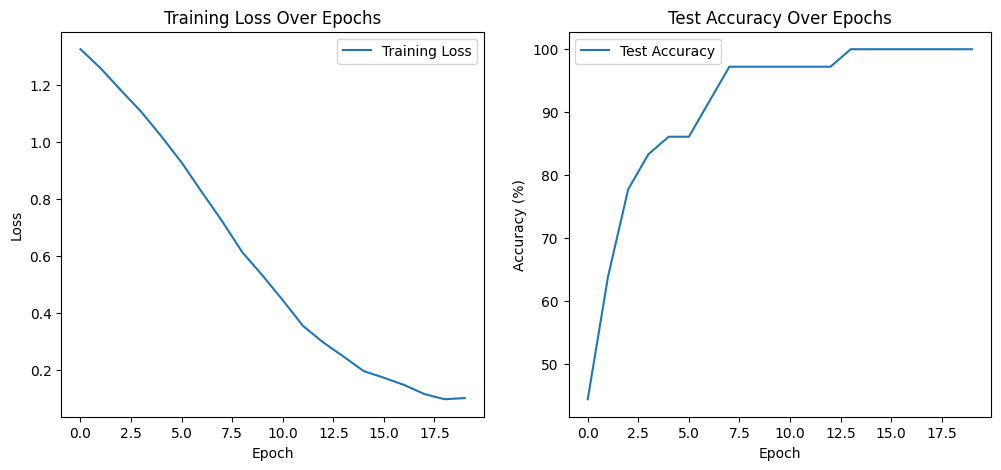

In [13]:
# 학습 결과 시각화
plt.figure(figsize=(12, 5))

# 손실 변화 그래프
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Epochs')
plt.legend()

# 정확도 변화 그래프
plt.subplot(1, 2, 2)
plt.plot(test_accuracies, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Test Accuracy Over Epochs')
plt.legend()

plt.show()